# Notebook 06 - Model Evaluation

## Objective
Evaluate the trained CNN model for ECG classification.

## Scope
This notebook performs:
- dataset loading
- label loading from CSV
- train/validation/test split
- model loading
- inference on test set
- accuracy / precision / recall / F1-score
- confusion matrix
- misclassification analysis
- class-wise performance summary

⚠️ Adjust paths if needed to match your local project structure.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_recall_fscore_support
)

import tensorflow as tf

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


## 1. File paths

In [2]:
X_path = '../data/processed/cnn_X.npy'
y_path = '../data/processed/cnn_y.csv'
model_path = '../models/cnn_ecg_best.keras'

print('X exists:', os.path.exists(X_path))
print('y exists:', os.path.exists(y_path))
print('model exists:', os.path.exists(model_path))

X exists: True
y exists: True
model exists: True


In [3]:
if not os.path.exists(X_path):
    raise FileNotFoundError(f'File not found: {X_path}')
if not os.path.exists(y_path):
    raise FileNotFoundError(f'File not found: {y_path}')
if not os.path.exists(model_path):
    raise FileNotFoundError(f'File not found: {model_path}')

X = np.load(X_path)
y_df = pd.read_csv(y_path)
y = y_df['arrhythmia_label'].astype(str).values

print('X shape:', X.shape)
print('y shape:', y.shape)
print('First labels:', y[:10])

X shape: (23005, 3600)
y shape: (23005,)
First labels: ['supraventricular' 'supraventricular' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal']


## 2. Input formatting and normalization

In [4]:
if X.ndim == 2:
    X = X[..., np.newaxis]
elif X.ndim == 3:
    pass
else:
    raise ValueError(f'Unsupported X shape: {X.shape}')

X_mean = X.mean(axis=1, keepdims=True)
X_std = X.std(axis=1, keepdims=True) + 1e-8
X_norm = (X - X_mean) / X_std

print('Adjusted X shape:', X_norm.shape)

Adjusted X shape: (23005, 3600, 1)


## 3. Label encoding

In [5]:
label_values = np.unique(y)
label_to_index = {label: idx for idx, label in enumerate(label_values)}
index_to_label = {idx: label for label, idx in label_to_index.items()}

y_enc = np.array([label_to_index[v] for v in y])

print('Classes:', label_values)
print('Mapping:', label_to_index)

Classes: ['fusion' 'normal' 'other' 'supraventricular' 'ventricular']
Mapping: {'fusion': 0, 'normal': 1, 'other': 2, 'supraventricular': 3, 'ventricular': 4}


## 4. Same split strategy as training

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_norm, y_enc, test_size=0.30, random_state=42, stratify=y_enc
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print('Train:', X_train.shape, y_train.shape)
print('Val:  ', X_val.shape, y_val.shape)
print('Test: ', X_test.shape, y_test.shape)

Train: (16103, 3600, 1) (16103,)
Val:   (3451, 3600, 1) (3451,)
Test:  (3451, 3600, 1) (3451,)


## 5. Load trained model

In [7]:
model = tf.keras.models.load_model(model_path)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3596, 32)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3596, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1798, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1794, 64)       │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1794, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 897, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 895, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 895, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 447, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57216)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,323,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,080,657 (84.23 MB)

 Trainable params: 7,360,069 (28.08 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 14,720,140 (56.15 MB)

## 6. Test inference

In [8]:
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

print('Prediction shape:', y_pred_prob.shape)

Prediction shape: (3451, 5)


## 7. Global metrics

In [9]:
acc = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)

print(f'Accuracy : {acc:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1-score : {f1:.4f}')

Accuracy : 0.9348
Precision: 0.9350
Recall   : 0.9348
F1-score : 0.9339


In [10]:
report = classification_report(
    y_test,
    y_pred,
    target_names=[str(index_to_label[i]) for i in range(len(label_values))],
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
fusion,1.000000,0.454545,0.625000,11.000000
normal,0.946976,0.968234,0.957487,2361.000000
other,0.846154,0.956522,0.897959,92.000000
supraventricular,0.949495,0.789916,0.862385,238.000000
ventricular,0.902740,0.879840,0.891143,749.000000
accuracy,0.934802,0.934802,0.934802,0.934802
macro avg,0.929073,0.809811,0.846795,3451.000000
weighted avg,0.935030,0.934802,0.933882,3451.000000


## 8. Confusion matrix

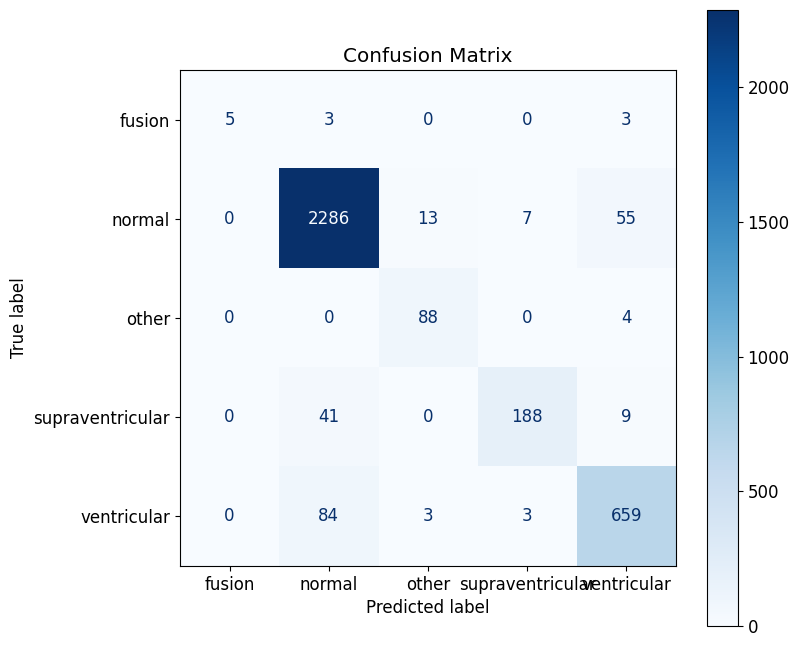

In [11]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[str(index_to_label[i]) for i in range(len(label_values))]
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

## 9. Misclassification analysis

In [12]:
mis_idx = np.where(y_test != y_pred)[0]
print(f'Number of misclassified samples: {len(mis_idx)}')

Number of misclassified samples: 225


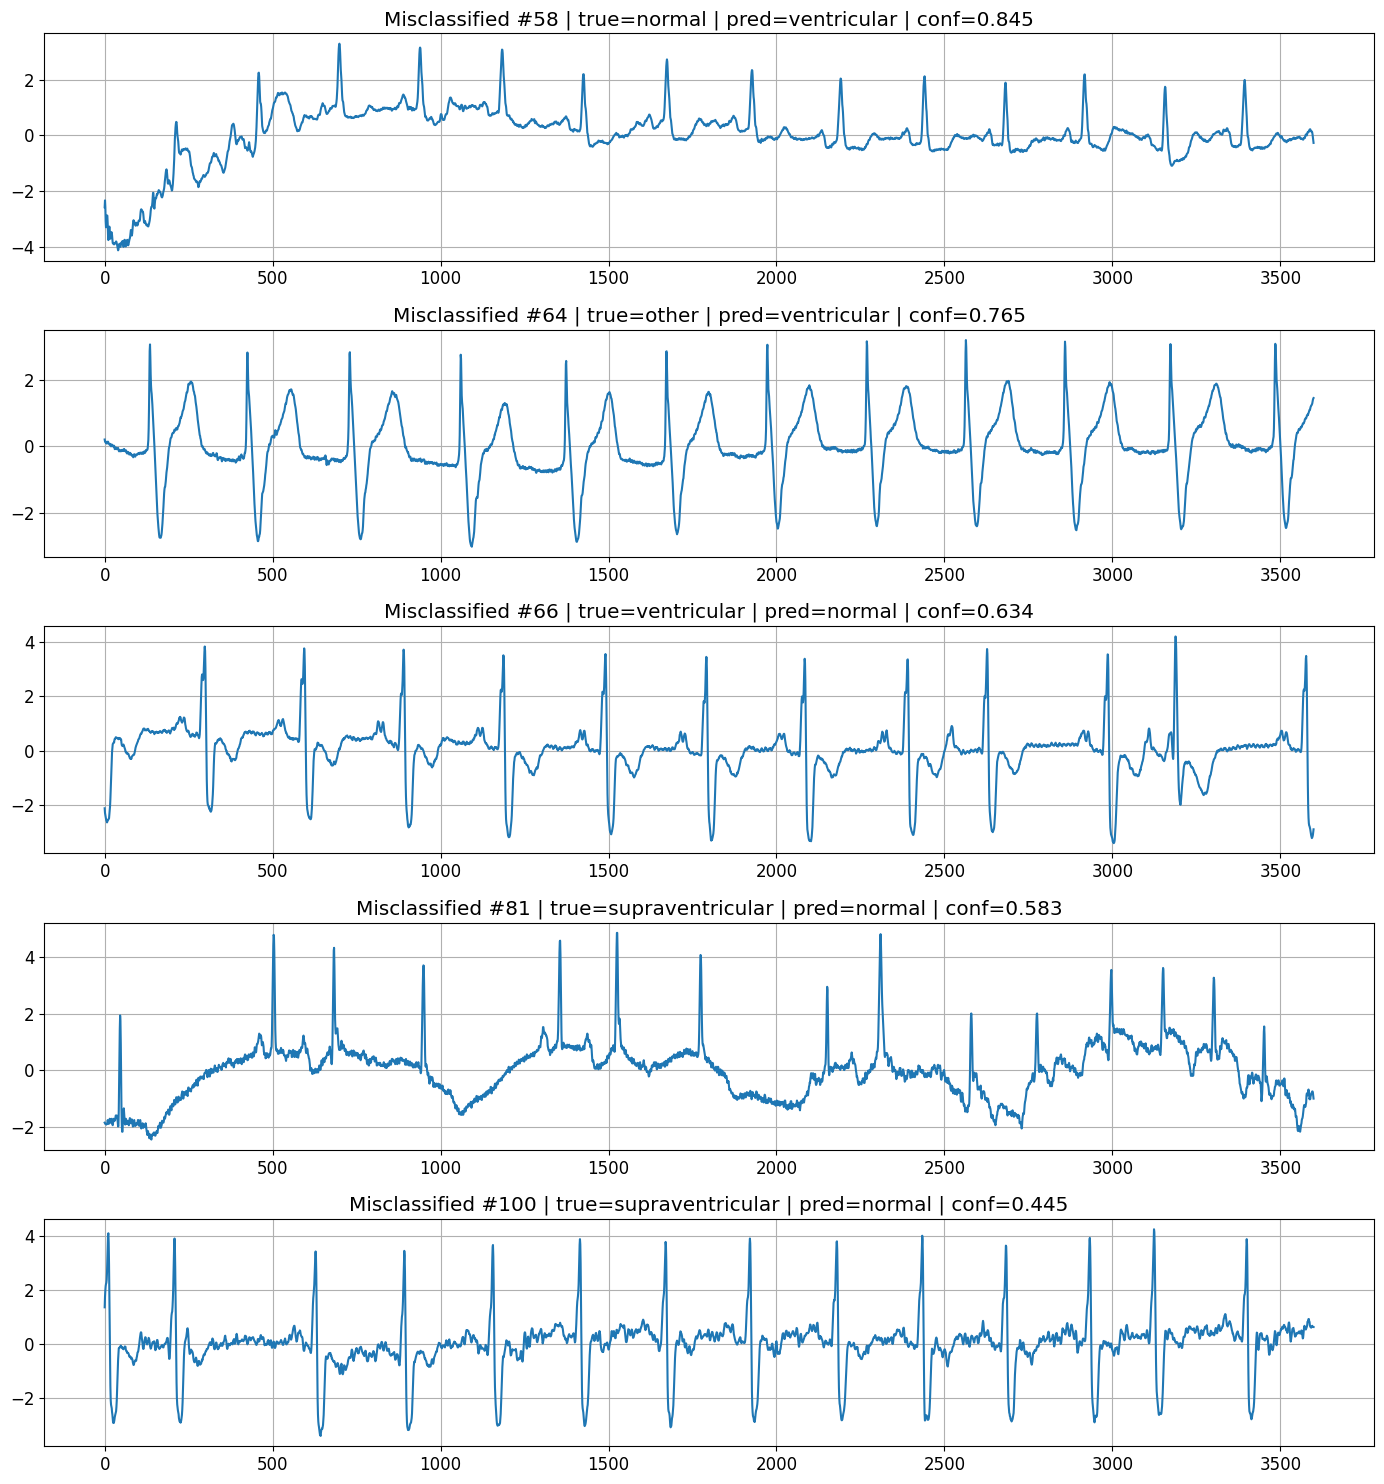

In [13]:
n_show = min(5, len(mis_idx))

if n_show > 0:
    fig, axes = plt.subplots(n_show, 1, figsize=(14, 3 * n_show), sharex=False)

    if n_show == 1:
        axes = [axes]

    for i, idx in enumerate(mis_idx[:n_show]):
        signal = X_test[idx].squeeze()
        true_label = index_to_label[y_test[idx]]
        pred_label = index_to_label[y_pred[idx]]
        confidence = np.max(y_pred_prob[idx])

        axes[i].plot(signal)
        axes[i].set_title(f'Misclassified #{idx} | true={true_label} | pred={pred_label} | conf={confidence:.3f}')
        axes[i].grid(True)

    plt.tight_layout()
    plt.show()
else:
    print('No misclassified samples to display.')

## 10. Correct classification examples

In [14]:
correct_idx = np.where(y_test == y_pred)[0]
print(f'Number of correctly classified samples: {len(correct_idx)}')

Number of correctly classified samples: 3226


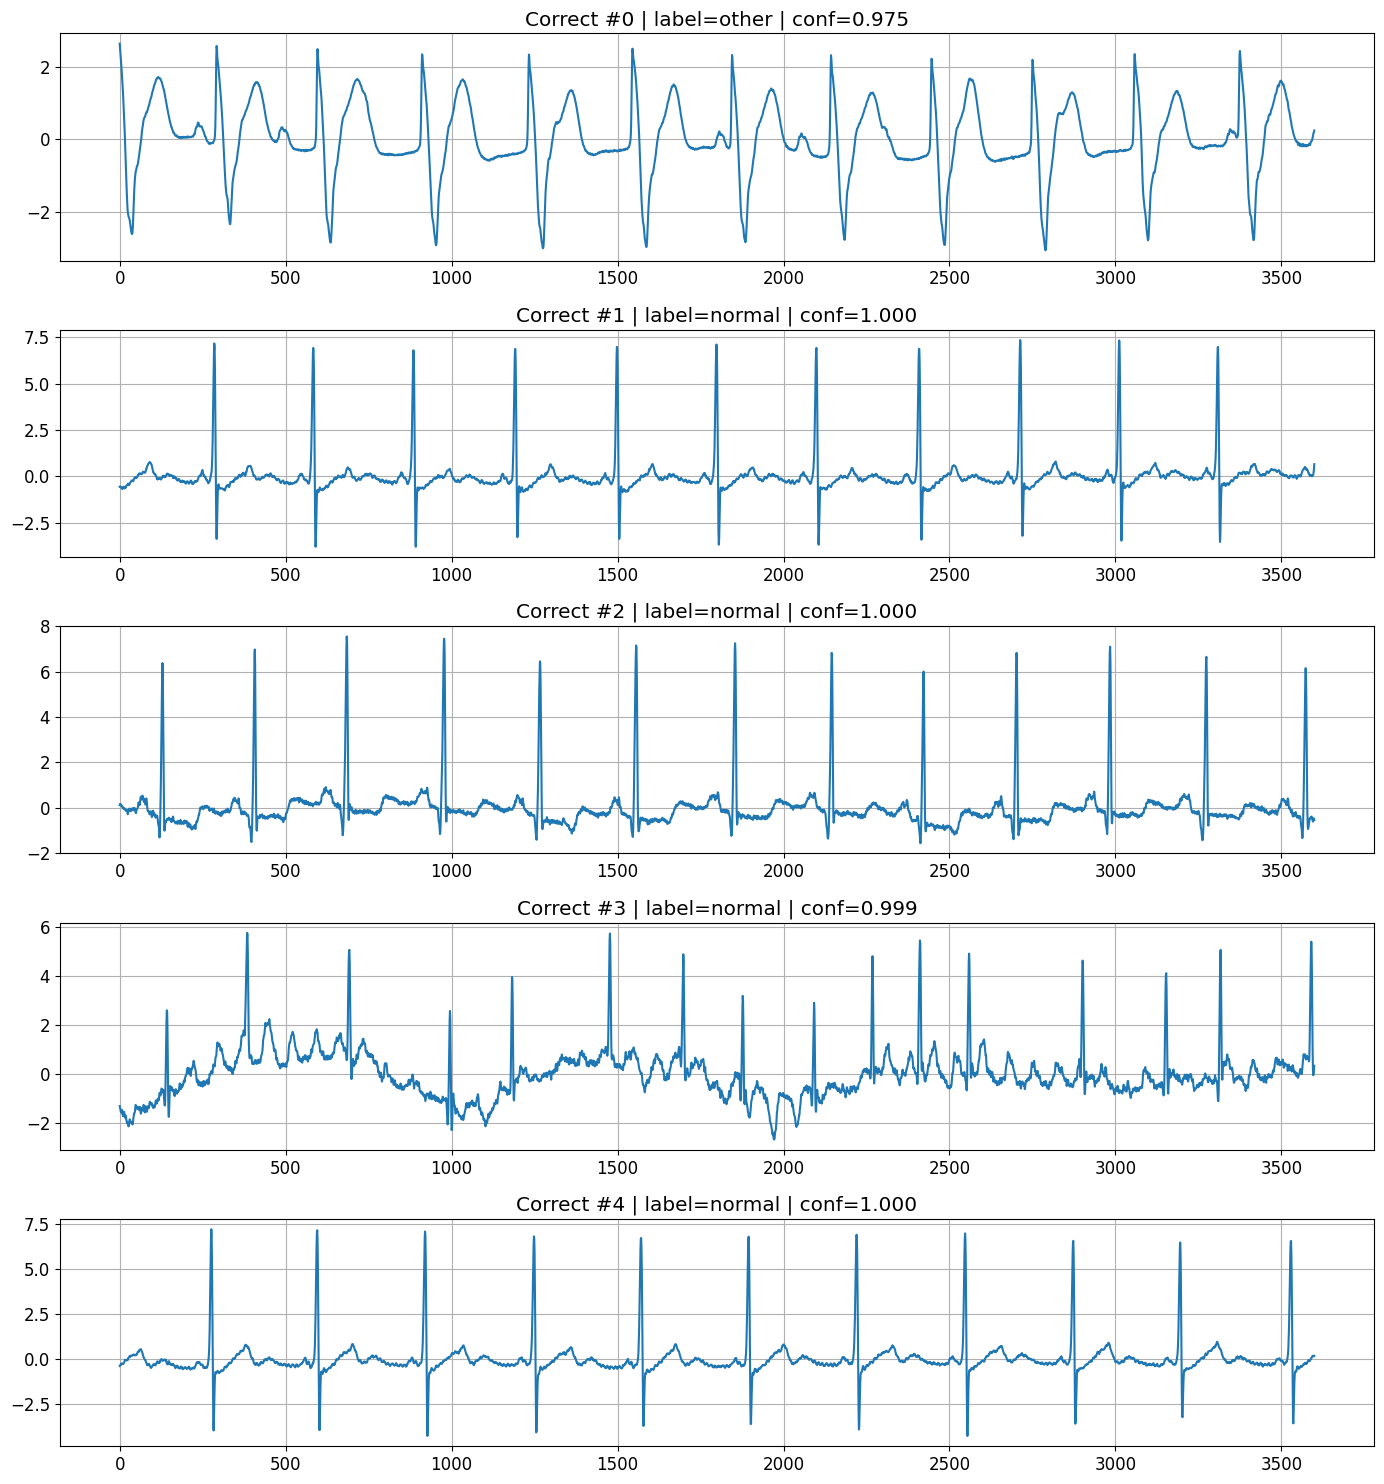

In [15]:
n_show = min(5, len(correct_idx))

if n_show > 0:
    fig, axes = plt.subplots(n_show, 1, figsize=(14, 3 * n_show), sharex=False)

    if n_show == 1:
        axes = [axes]

    for i, idx in enumerate(correct_idx[:n_show]):
        signal = X_test[idx].squeeze()
        true_label = index_to_label[y_test[idx]]
        confidence = np.max(y_pred_prob[idx])

        axes[i].plot(signal)
        axes[i].set_title(f'Correct #{idx} | label={true_label} | conf={confidence:.3f}')
        axes[i].grid(True)

    plt.tight_layout()
    plt.show()
else:
    print('No correctly classified samples to display.')

## 11. Class-wise summary

In [16]:
class_summary = report_df.loc[[str(index_to_label[i]) for i in range(len(label_values))], ['precision', 'recall', 'f1-score', 'support']]
class_summary

,precision,recall,f1-score,support
fusion,1.000000,0.454545,0.625000,11.0
normal,0.946976,0.968234,0.957487,2361.0
other,0.846154,0.956522,0.897959,92.0
supraventricular,0.949495,0.789916,0.862385,238.0
ventricular,0.902740,0.879840,0.891143,749.0


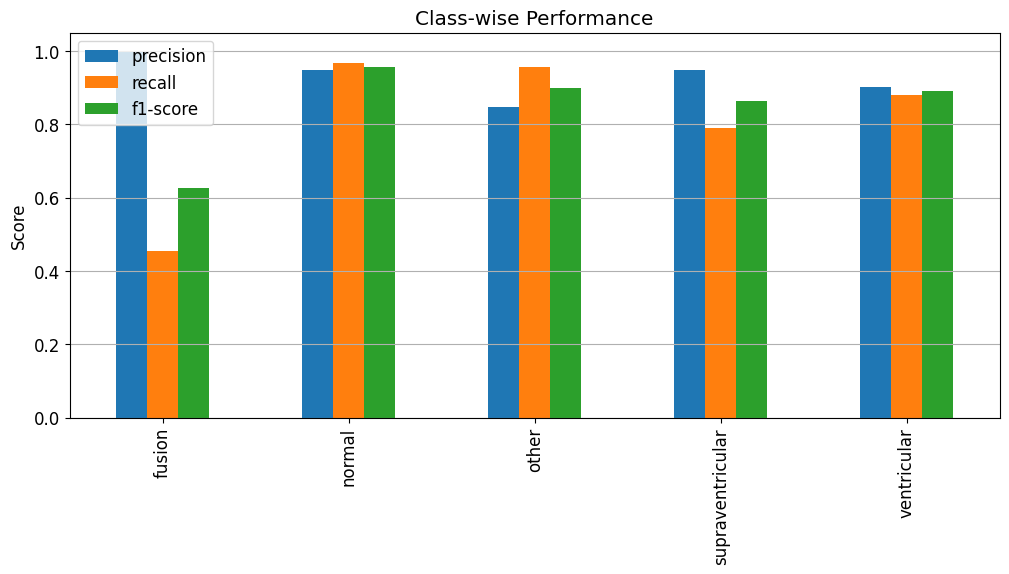

In [17]:
class_summary[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(12, 5))
plt.title('Class-wise Performance')
plt.ylabel('Score')
plt.grid(True, axis='y')
plt.show()

## 12. Save evaluation report

In [18]:
os.makedirs('../reports', exist_ok=True)
report_df.to_csv('../reports/cnn_classification_report.csv', index=True)
class_summary.to_csv('../reports/cnn_class_summary.csv', index=True)

with open('../reports/cnn_classification_report.txt', 'w', encoding='utf-8') as f:
    f.write(f'Accuracy: {acc:.4f}\n')
    f.write(f'Precision: {precision:.4f}\n')
    f.write(f'Recall: {recall:.4f}\n')
    f.write(f'F1-score: {f1:.4f}\n\n')
    f.write(classification_report(
        y_test,
        y_pred,
        target_names=[str(index_to_label[i]) for i in range(len(label_values))],
        zero_division=0
    ))

print('Saved reports to ../reports/')

Saved reports to ../reports/


## 13. Final summary

In [19]:
summary = pd.DataFrame({
    'Metric': ['Test samples', 'Classes', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'Misclassified samples'],
    'Value': [len(X_test), len(label_values), acc, precision, recall, f1, len(mis_idx)]
})
summary

,Metric,Value
0,Test samples,3451.000000
1,Classes,5.000000
2,Accuracy,0.934802
3,Precision,0.935030
4,Recall,0.934802
5,F1-score,0.933882
6,Misclassified samples,225.000000


In [20]:
print('Notebook 06 - Model Evaluation completed successfully.')
print('Generated outputs:')
print('- global classification metrics')
print('- confusion matrix')
print('- class-wise report')
print('- misclassification analysis')
print('- saved reports in ../reports/')

Notebook 06 - Model Evaluation completed successfully.
Generated outputs:
- global classification metrics
- confusion matrix
- class-wise report
- misclassification analysis
- saved reports in ../reports/
